In [1]:
import matplotlib.pyplot as plt
import mplhep as hep
import pandas as pd
import numpy as np
import awkward as ak
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import config
import mucol as mu
hep.style.use(hep.style.CMS)

data = {}
for b in tqdm(config.Brange, desc="Loading parquet files", unit="file"):
    B = f"{b:02d}"
    data[f"B{B}"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B{B}.parquet")

b00 = data["B00"].prod
b03 = data["B03"].prod
b04 = data["B04"].prod
b05 = data["B05"].prod
b06 = data["B06"].prod
b07 = data["B07"].prod
b08 = data["B08"].prod
b09 = data["B09"].prod
b10 = data["B10"].prod

Loading parquet files:   0%|          | 0/9 [00:00<?, ?file/s]

In [2]:
data["B00"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B00.parquet")
print("B00: done!")
data["B03"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B03.parquet")
print("B03: done!")
data["B04"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B04.parquet")
print("B04: done!")
data["B05"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B05.parquet")
print("B05: done!")
data["B06"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B06.parquet")
print("B06: done!")

B00: done!
B03: done!
B04: done!
B05: done!
B06: done!


In [ ]:
data["B07"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B07.parquet")
print("B07: done!")
data["B08"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B08.parquet")
print("B08: done!")
data["B09"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B09.parquet")
print("B09: done!")
data["B10"] = ak.from_parquet(f"{config.nfs_scratch_simData}/{config.simName}_B10.parquet")
print("B10: done!")

In [4]:
b03.PiPlus.fields

['id',
 'energy',
 'p',
 'x',
 'y',
 'z',
 'cx',
 'cy',
 'cz',
 'time',
 'gen',
 'event',
 'Mother',
 'ICODE',
 'px',
 'py',
 'pt',
 'pz',
 'eta',
 'run',
 'location']

In [45]:
PARTICLE_CODE = {
    1: "Proton",
    2: "AProton",
    8: "Neutron",
}

# PARTICLE_NAME = {name: code for code, name in PARTICLE_CODE.items()}

# PARTICLE_NAME = {
#     name.casefold(): code
#     for code, name in PARTICLE_CODE.items()
# }

# class CaseInsensitiveDict(dict):
#     def __init__(self, *args, **kwargs):
#         super().__init__()
#         self.update(*args, **kwargs)

#     def __getitem__(self, key):
#         return super().__getitem__(key.casefold())

#     def __setitem__(self, key, value):
#         super().__setitem__(key.casefold(), value)

class CaseInsensitiveDict(dict):
    def __init__(self, data=None):
        super().__init__()
        if data is not None:
            for key, value in data.items():
                self[key] = value

    def __getitem__(self, key):
        return super().__getitem__(key.casefold())

    def __setitem__(self, key, value):
        super().__setitem__(key.casefold(), value)

    def __contains__(self, key):
        return super().__contains__(key.casefold())

    def get(self, key, default=None):
        return super().get(key.casefold(), default)



PARTICLE_NAME = CaseInsensitiveDict({
    name: code for code, name in PARTICLE_CODE.items()
})


PARTICLE_NAME["neuTron"]

8

In [17]:
np.unique(ak.flatten(b00.PiPlus.Mother))

<Array [1, 2, 8, 9, 13, 14, 15, ..., 20, 21, 23, 24, 25, 34] type='15 * int64'>

In [2]:
rows = []

for b in config.Brange:
    B = f"B{b:02d}"
    d = data[B].prod.PiMinus
    esc = data[B].esc.PiMinus
    prod = data[B].prod.PiMinus

    # Number of pions in each event
    n_prod = ak.sum(ak.num(prod, axis=1))
    n_esc  = ak.sum(ak.num(esc,  axis=1))
    n_proton = ak.sum(ak.num(d[d.Mother == 1],  axis=1))
    n_aproton = ak.sum(ak.num(d[d.Mother == 2],  axis=1))
    n_neutron = ak.sum(ak.num(d[d.Mother == 8],  axis=1))
    n_aneutron = ak.sum(ak.num(d[d.Mother == 9],  axis=1))
    n_pip = ak.sum(ak.num(d[d.Mother == 13],  axis=1))
    n_pin = ak.sum(ak.num(d[d.Mother == 14],  axis=1))
    n_kp = ak.sum(ak.num(d[d.Mother == 15],  axis=1))
    n_kn = ak.sum(ak.num(d[d.Mother == 16],  axis=1))
    n_lambda = ak.sum(ak.num(d[d.Mother == 17],  axis=1))
    n_sigman = ak.sum(ak.num(d[d.Mother == 20],  axis=1))
    n_sigmap = ak.sum(ak.num(d[d.Mother == 21],  axis=1))
    n_pizero = ak.sum(ak.num(d[d.Mother == 23],  axis=1))
    n_kzero = ak.sum(ak.num(d[d.Mother == 24],  axis=1))
    n_akzero = ak.sum(ak.num(d[d.Mother == 25],  axis=1))
    n_xizero = ak.sum(ak.num(d[d.Mother == 34],  axis=1))


    rows.append({
        "B (T)": b,
        "Produced": n_prod,
        # "Escaped": n_esc,
        "Proton": n_proton/n_prod,
        # "AProton": n_aproton/n_prod,
        "Neutron": n_neutron/n_prod,
        # "ANeutron": n_aneutron/n_prod,
        "Pi+": n_pip/n_prod,
        "Pi-": n_pin/n_prod,
        # "Pi-0": n_pizero/n_prod,
        "Kaon+": n_kp/n_prod,
        "Kaon-": n_kn/n_prod,
        "K-zero": n_kzero/n_prod,
        "AK-zero": n_akzero/n_prod,
        "Lambda": n_lambda/n_prod,
        "Sigma-": n_sigman/n_prod,
        "Sigma+": n_sigmap/n_prod,
        # "Xi-zero": n_xizero/n_prod
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(index=False)))

B (T),Produced,Proton,Neutron,Pi+,Pi-,Kaon+,Kaon-,K-zero,AK-zero,Lambda,Sigma-,Sigma+
0,691347,0.940437,0.022424,0.009369,0.021407,0.000171,0.000146,0.001626,0.000363,0.002504,0.001391,0.000140
3,734269,0.939925,0.022662,0.009408,0.021581,0.000169,0.000163,0.001591,0.000391,0.002679,0.001329,0.000095
4,735442,0.940570,0.022529,0.009223,0.021346,0.000203,0.000126,0.001575,0.000334,0.002486,0.001471,0.000114
5,733079,0.940211,0.022998,0.009041,0.021291,0.000192,0.000154,0.001621,0.000336,0.002569,0.001475,0.000108
6,736050,0.940671,0.022391,0.008855,0.021572,0.000194,0.000164,0.001643,0.000353,0.002622,0.001388,0.000137
7,735055,0.940472,0.022680,0.009152,0.021319,0.000188,0.000165,0.001573,0.000343,0.002607,0.001390,0.000102
8,735071,0.940456,0.022459,0.009111,0.021531,0.000159,0.000127,0.001556,0.000344,0.002668,0.001468,0.000112
9,734199,0.939881,0.022792,0.009188,0.021685,0.000174,0.000151,0.001606,0.000360,0.002631,0.001396,0.000118
10,734193,0.939512,0.022652,0.009184,0.021966,0.000206,0.000157,0.001681,0.000361,0.002709,0.001434,0.000127


IndexError: index 12 is out of bounds for axis 0 with size 12

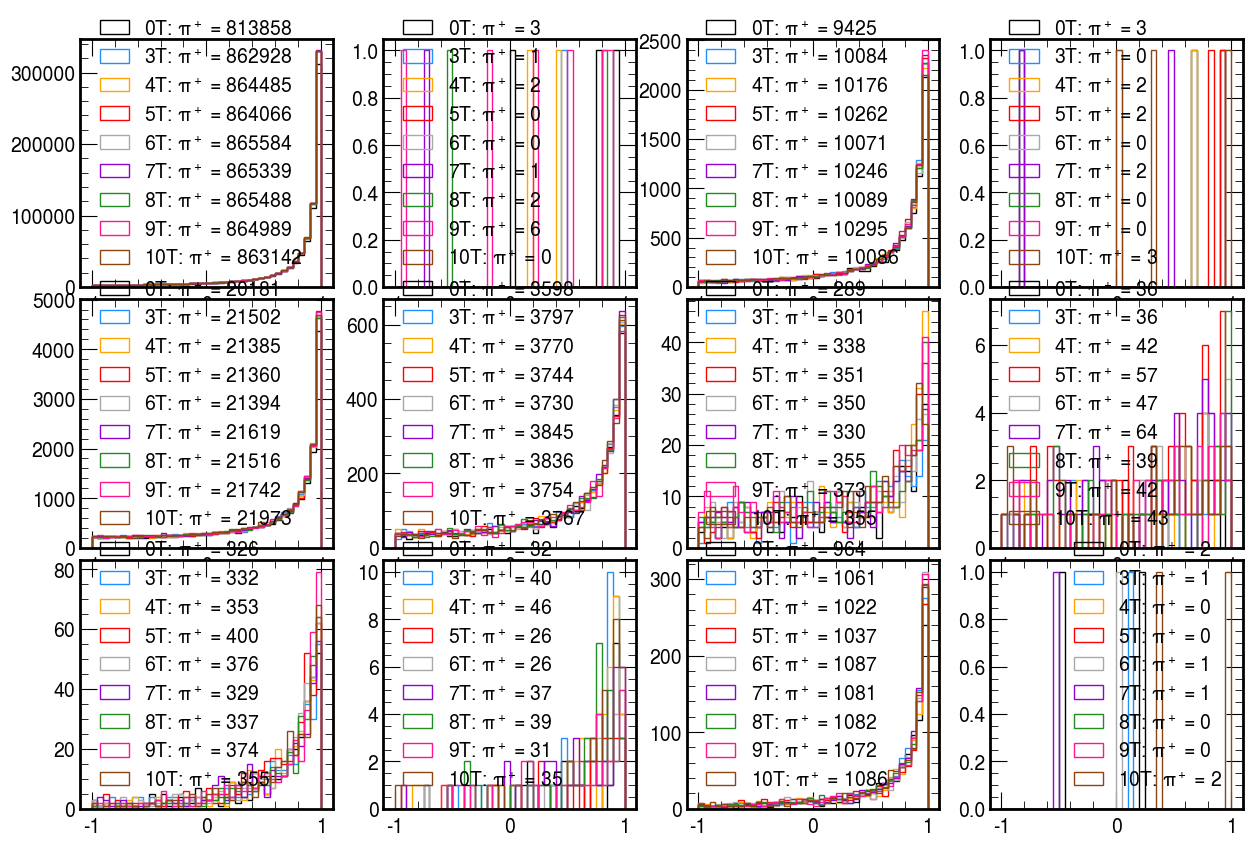

In [24]:
# def plotFromMother(parameter):
mother = np.unique(ak.flatten(b00.PiPlus.Mother))
fig, ax = plt.subplots(3, 4, figsize=(15, 10),
                       sharex = False,
                       gridspec_kw={"hspace": 0.05})
ax = ax.flatten()
plt.tick_params(axis='both', labelsize=14)
bins = np.linspace(-1,1,41)

for i in range(len(mother)):
    for b in config.Brange:
        Bfield = f"B{b:02d}"
        ax[i] = mu.draw_hist(ax[i], 
                         ak.flatten(data[Bfield].prod.PiPlus.cz[data[Bfield].prod.PiPlus.Mother == mother[i]]), bins,
                         f'{b}T: $\\pi^+$ = {ak.count(data[Bfield].prod.PiPlus.cz[data[Bfield].prod.PiPlus.Mother == mother[i]])}',
                         color = config.COLOR_MAP[Bfield])

Text(0.95, 0.07, 'Pions at det4')

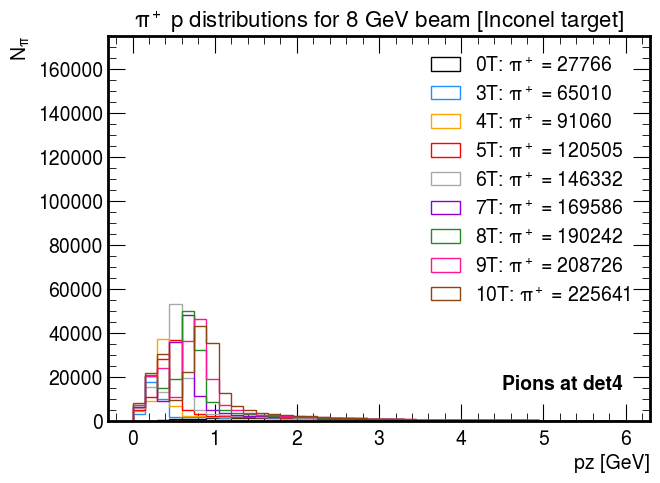

In [75]:
lower = 0
upper = 50

bins = np.linspace(0,6,41)
fig, ax = plt.subplots(1, 1, 
                       figsize=(7, 5))
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_mom = (data[Bfield].esc.PiPlus.p >= lower) & (data[Bfield].esc.PiPlus.p <= upper)
    det1_mom = (data[Bfield].det1.PiPlus.p >= lower) & (data[Bfield].det1.PiPlus.p <= upper)

    cT = np.sqrt(data[Bfield].det2.PiPlus.cx**2 + data[Bfield].det2.PiPlus.cy**2)
    
    ax = mu.draw_hist(ax, 
                     ak.flatten(data[Bfield].det4.PiPlus.pz), bins,
                     f'{b}T: $\\pi^+$ = {ak.count(data[Bfield].det4.PiPlus.p)}',
                     color = config.COLOR_MAP[Bfield])

# ax.set_yscale("log")
# ax.set_yscale("log")
# ax.set_xlabel('Cos $\\theta_z$', fontsize=14)
ax.set_xlabel('pz [GeV]', fontsize=14)
ax.set_ylabel(r'$N_{\pi}$', fontsize=14)

ax.set_ylim(0,175000)

ax.set_title(fr'$\pi^+$ p distributions for {data["B09"].metadata.beamEnergy} GeV beam [{data["B09"].metadata.target.material} target]', fontsize=16)

ax.text(
    0.95, 0.07,
    "Pions at det4",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)